In [19]:
import pandas as pd
import numpy as np

In [3]:
from gensim.models.poincare import PoincareModel, PoincareKeyedVectors, PoincareRelations

In [5]:
path = 'C:/Users/master/Documents/github/NLP_study/code/poincare'

from gzip import open as gopen

communities_truth = path+"/com-amazon.ungraph.txt.gz"

communities = []

with gopen(communities_truth,mode='rb') as gin:
    for iline,line in enumerate(gin.readlines()):
        line = line.decode('ascii')
        if line[0].isnumeric():
            toks = line.split("\t")
            communities.append( list(int(tok) for tok in toks) )
        if iline<=10:print(line.rstrip("\n"))

# we sort the communities by size
communities.sort(key=lambda x: len(x),reverse=True)

# Undirected graph: ../../data/output/amazon.ungraph.txt
# Amazon
# Nodes: 334863 Edges: 925872
# FromNodeId	ToNodeId
1	88160
1	118052
1	161555
1	244916
1	346495
1	444232
1	447165


In [9]:

pd.DataFrame(communities)

,0,1
0,1,88160
1,1,118052
2,1,161555
3,1,244916
4,1,346495
...,...,...
925867,548343,548378
925868,548354,548356
925869,548368,548454
925870,548391,548411


In [14]:
model = PoincareModel(train_data=communities) #, size=2 , burn_in=10 /train a bidimensional embedding with 10 burn-in epochs
model.train(epochs=50) # , print_every=25

In [39]:
vectors = model.kv.vectors

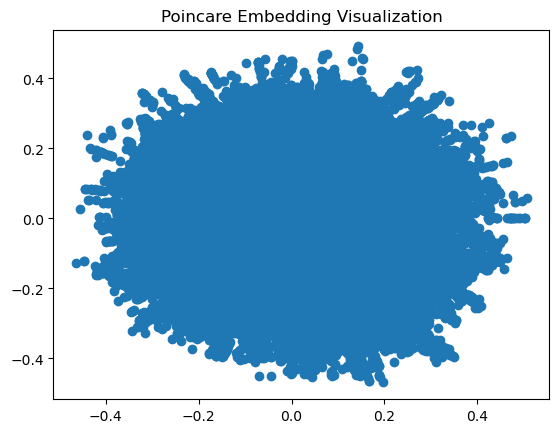

In [43]:
import matplotlib.pyplot as plt

# 모델 벡터 추출 후 시각화 (2D일 경우)
vectors = model.kv.vectors
plt.scatter(vectors[:, 0], vectors[:, 1])
plt.title('Poincare Embedding Visualization')
plt.show()

----

In [64]:
path = 'C:/Users/master/Documents/github/NLP_study/code/poincare'
from gzip import open as gopen

communities_truth = path+"/com-amazon.top5000.cmty.txt.gz"

communities = []

with gopen(communities_truth,mode='rb') as gin:
    for iline,line in enumerate(gin.readlines()):
        line = line.decode('ascii')
        if line[0].isnumeric():
            toks = line.split("\t")
            communities.append( list(int(tok) for tok in toks) )
        if iline<=10:print(line.rstrip("\n"))

# we sort the communities by size
communities.sort(key=lambda x: len(x),reverse=True)

164985	225214	232761
105089	282815	331787
167906	288975	421279	442612	451312
69880	231953	518997	523128
135499	160294	304770
112813	112814	112821	112823
112813	112814	112821	112823
199372	399560	447268	471226	522928
179001	391697	412528
21166	207188	405926	531532	540207
118948	191846	209822	455700	482725


In [66]:
from itertools import combinations

communities2 = []

for sublist in communities:
    # 각 서브 리스트에서 두 쌍씩 만들기
    pairs = combinations(sublist, 2)
    # 1~5 사이의 값만 포함하는 쌍을 필터링하여 결과에 추가
    communities2.extend([pair for pair in pairs if all(1 <= x <= 200000 for x in pair)])
communities2 = list(set(communities2))
print(len(communities2))

51025


In [68]:
import numpy as np

In [70]:
model2 = PoincareModel(train_data=communities2, size=2) #, size=2 , burn_in=10 /train a bidimensional embedding with 10 burn-in epochs
model2.train(epochs=10) # , print_every=25

In [32]:
# model = PoincareModel(communities2, negative=2)
# model.train(epochs=50)

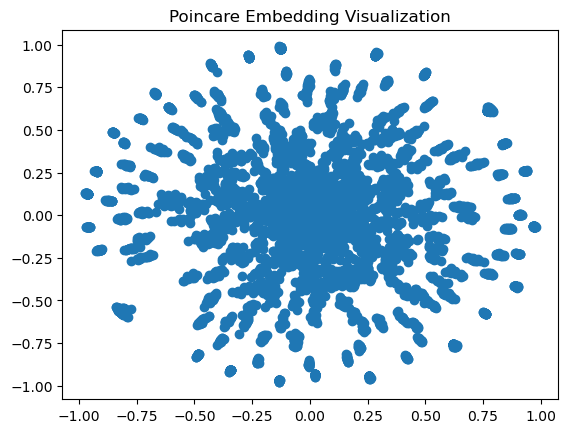

In [71]:
import matplotlib.pyplot as plt

# 모델 벡터 추출 후 시각화 (2D일 경우)
vectors = model2.kv.vectors
plt.scatter(vectors[:, 0], vectors[:, 1])
plt.title('Poincare Embedding Visualization')
plt.show()

In [72]:
model2.kv.vectors.shape

(5802, 2)

In [84]:
model2.kv.index_to_key[model2.kv.index_to_key==47559]

47559

In [90]:
model2.kv.get_vector(47559)

array([0.28344978, 0.94312702])

In [100]:
communities_xy = [ np.vstack(  [ model2.kv.get_vector(x) for x in community ] ) for community in communities2 ]

In [112]:
from bokeh.io import output_file, output_notebook, show
from bokeh.plotting import figure
from bokeh.transform import linear_cmap
from bokeh.util.hex import hexbin
from bokeh.models import HoverTool
from bokeh import colors


p = figure(title="Amazon purchases network 2D embedding after 90 epochs", 
     match_aspect=True, background_fill_color='#440154')
p.grid.visible = False

bins = p.hexbin(model.kv.vectors[:,0], model.kv.vectors[:,1], 0.01, hover_color="pink", hover_alpha=0.8)

# trick to get a different color for each community
points_colors = colors.named.__all__

# loop over communities and add them to the plot
for icomm, (col, comm) in enumerate(zip(points_colors, communities_xy)):
    name = str(icomm)
    
    # Scatter points and capture the returned glyph_renderer
    renderer = p.scatter(comm[:, 0], comm[:, 1], color=col, alpha=0.5, name=name)
    
    # Add hover tool for the specific renderer
    hover = HoverTool(renderers=[renderer], tooltips=[('community', name)])
    p.add_tools(hover)

show(p)

In [122]:
from bokeh.io import output_file, output_notebook, show
from bokeh.plotting import figure, ColumnDataSource
from bokeh.transform import linear_cmap
from bokeh.util.hex import hexbin
from bokeh.models import HoverTool
from bokeh import colors

p = figure(title="Amazon purchases network 2D embedding after 90 epochs", 
           match_aspect=True, background_fill_color='#440154')
p.grid.visible = False

# trick to get a different color for each community
points_colors = colors.named.__all__

# loop over communities and add them to the plot
for icomm, (col, comm) in enumerate(zip(points_colors, communities_xy)):
    
    unique_comm = np.unique(comm, axis=0)  # 커뮤니티 내의 중복 좌표 제거
    if len(unique_comm) != len(comm):
        print(f"Community {icomm} has duplicate points.")
    comm = unique_comm
    name = str(icomm)
    
    # Create a ColumnDataSource for the community
    source = ColumnDataSource(data={'x': comm[:, 0], 'y': comm[:, 1], 'community': [name] * len(comm)})
    
    # Scatter points using the ColumnDataSource
    p.scatter('x', 'y', source=source, color=col, alpha=0.5, name=name)
    
    # Add community number as text glyph on top of points
    p.text(x='x', y='y', text='community', source=source, text_font_size='10pt', 
           text_color='white', text_align='center', text_baseline='middle')

# Show the plot
show(p)

----

In [1]:
!pip install gensim

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/60.3 kB ? eta -:--:--
   ---------------------------------------- 60.3/60.3 kB 1.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/14.9 MB ? eta -:--:--
   -- ------------------------------------- 0.8/14.9 MB 16.3 MB/s eta 0:00:01
   ---- ----------------------------------- 1.5/14.9 MB 15.8 MB/s eta 0:00:01
   ----- ---------------------------------- 2.2/14.9 MB 15.5 MB/s eta 0:00:01
   ------- -------------------------------- 2.9/14.9 MB 15.6 MB/s eta 0:00:01
   --------- ------------------------------ 3.6/14.9 MB 15.3 MB/s eta 0:00:01
   ----------- ---------------------------- 4.2/14.9 MB 14.7 MB/s eta 0:00:01
   ------------ --------------------------- 4.5/14.9 MB 14.4 MB/s eta 0:00:01
   ------------- ---------------

DEPRECATION: mecab-python 0.996-ko-0.9.2-msvc has a non-standard version number. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of mecab-python or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.


In [16]:
from gensim.models.poincare import PoincareModel
relations = [('kangaroo', 'marsupial'), ('kangaroo', 'mammal'), ('gib', 'cat')]
model = PoincareModel(relations, negative=2)
model.train(epochs=50)